In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 03 Evaluate

Evaluates the trained models, runs the mathematical dynamic threshold validation, and creates visual inspection plots for anomalies.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import EvalConfig
from src.evaluate import evaluate_model
from src.utils import read_json

### Run Base Evaluation

In [3]:
eval_cfg = EvalConfig(
    dataset_dir=DATASET_DIR,
    model_dir=MODEL_DIR,
    output_dir=RESULTS_DIR,
    model_mode="hybrid",
    eval_modes=("reconstruction", "forecasting", "hybrid"),
    split="test",
    use_synthetic_injection=True,
    include_gpt_in_stream=False,
    device="cuda",
)
eval_summary = evaluate_model(eval_cfg)
display(eval_summary["evaluation_summary"])

[evaluate] Evaluating mode=reconstruction


Reconstruction scoring:   0%|                                                                                 …

[evaluate] Evaluating mode=forecasting


Forecast scoring:   0%|                                                                                       …

[evaluate] Evaluating mode=hybrid


Reconstruction scoring:   0%|                                                                                 …

Forecast scoring:   0%|                                                                                       …

[evaluate] Completed evaluation in 64.0s


{'mode': 'hybrid',
 'static_threshold': 29057.083984375,
 'num_windows': 29176,
 'num_positive_windows': 4,
 'num_confirmed_alerts': 62,
 'num_gpt_decisions': 0,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 0.00015225450098903763,
 'roc_auc': 0.30753805018510905,
 'false_positive_rate': 0.0021253256547374196,
 'event_metrics': {'num_events': 1,
  'strict_detection_rate': 0.0,
  'relaxed_detection_rate': 0.0,
  'mean_detection_delay': None},
 'plots': {'confusion_matrix': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\hybrid\\confusion_matrix.png',
  'roc_curve': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\hybrid\\roc_curve.png',
  'pr_curve': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\hybrid\\pr_curve.png',
  'score_vs_threshold': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\research_smoke_auto\\hybrid\\score_vs_threshold.png',
  'recon_vs_forecast': 'C:\\Users\\kaspe\\D

### Dynamic Threshold Analysis
Using `.env` populated configurations, compute standard metrics.

In [4]:
hybrid_stream = pd.read_csv(RESULTS_DIR / "hybrid" / "realtime_stream_predictions.csv")

# Make sure dynamic threshold uses the exact anomaly_score variable (final_score)
anomaly_score = hybrid_stream['final_score'].values

dyn_percentile = eval_cfg.dynamic_threshold_percentile
z_threshold = eval_cfg.z_score_threshold
history_limit = eval_cfg.dynamic_threshold_history_limit

dynamic_thresholds = np.zeros_like(anomaly_score)
z_scores = np.zeros_like(anomaly_score)
candidate_flags = np.zeros_like(anomaly_score, dtype=bool)

for i in range(len(anomaly_score)):
    start_idx = max(0, i - history_limit)
    history = anomaly_score[start_idx:i]

    if len(history) > 5:
        dyn_thresh = np.percentile(history, dyn_percentile)
        mean_hist = np.mean(history)
        std_hist = np.std(history) + 1e-8
        z = (anomaly_score[i] - mean_hist) / std_hist
    else:
        dyn_thresh = anomaly_score[i]
        z = 0.0

    dynamic_thresholds[i] = dyn_thresh
    z_scores[i] = z
    candidate_flags[i] = (anomaly_score[i] > dyn_thresh) or (z > z_threshold)

hybrid_stream['calculated_dynamic_threshold'] = dynamic_thresholds
hybrid_stream['calculated_z_score'] = z_scores
hybrid_stream['is_candidate'] = candidate_flags

# Save evaluation outputs
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "hybrid").mkdir(parents=True, exist_ok=True)
hybrid_stream.to_csv(RESULTS_DIR / "hybrid" / "realtime_stream_predictions_enhanced.csv", index=False)
display(hybrid_stream[['window_id', 'final_score', 'calculated_dynamic_threshold', 'calculated_z_score', 'is_candidate']].head())

C:\Users\kaspe\AppData\Local\Temp\ipykernel_10192\566507728.py:1: DtypeWarning: Columns (0: z_score_reason) have mixed types. Specify dtype option on import or set low_memory=False.
  hybrid_stream = pd.read_csv(RESULTS_DIR / "hybrid" / "realtime_stream_predictions.csv")


,window_id,final_score,calculated_dynamic_threshold,calculated_z_score,is_candidate
0,0,0.057446,0.057446,0.0,False
1,1,0.058530,0.058530,0.0,False
2,2,0.076751,0.076751,0.0,False
3,3,0.103506,0.103506,0.0,False
4,4,0.051777,0.051777,0.0,False


### Visualization: Score Distributions

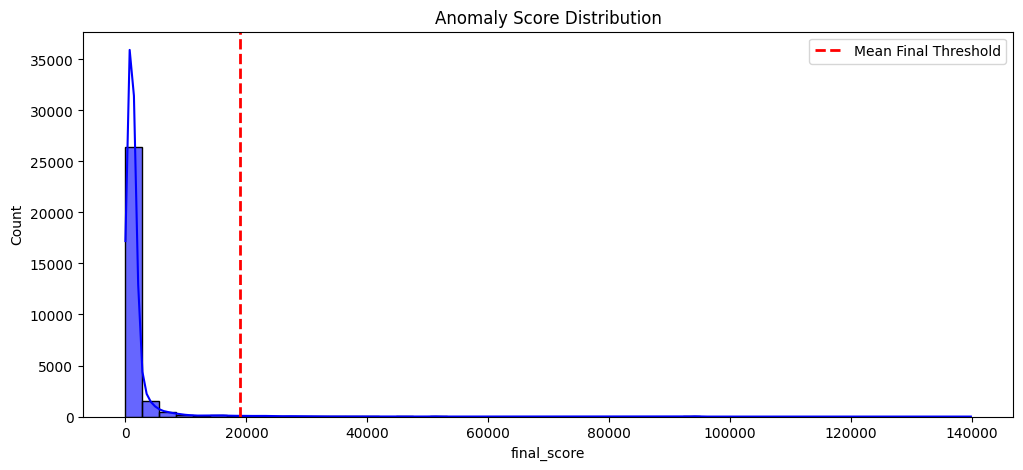

In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(hybrid_stream['final_score'], bins=50, kde=True, color='blue', alpha=0.6)
plt.axvline(hybrid_stream['final_threshold'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean Final Threshold')
plt.title('Anomaly Score Distribution')
plt.legend()
plt.savefig(RESULTS_DIR / 'hybrid' / 'anomaly_score_distribution.png')
plt.show()

### Visualization: Top Anomalous Windows

C:\Users\kaspe\AppData\Local\Temp\ipykernel_10192\575740904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_anomalies['window_id'].astype(str), y=top_anomalies['final_score'], palette='Reds_r')


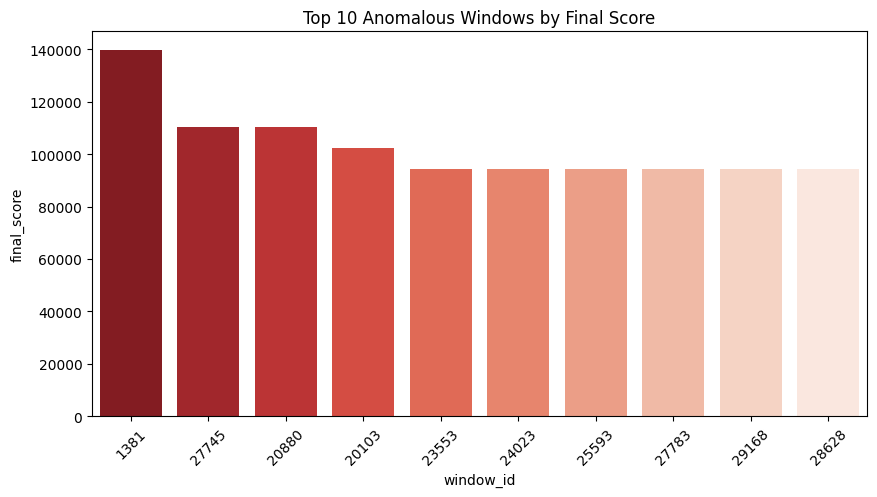

In [6]:
top_anomalies = hybrid_stream.sort_values(by='final_score', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_anomalies['window_id'].astype(str), y=top_anomalies['final_score'], palette='Reds_r')
plt.title('Top 10 Anomalous Windows by Final Score')
plt.xticks(rotation=45)
plt.savefig(RESULTS_DIR / 'hybrid' / 'top_anomalous_windows.png')
plt.show()

### Visualization: Paper-Style Time Series & Thresholds

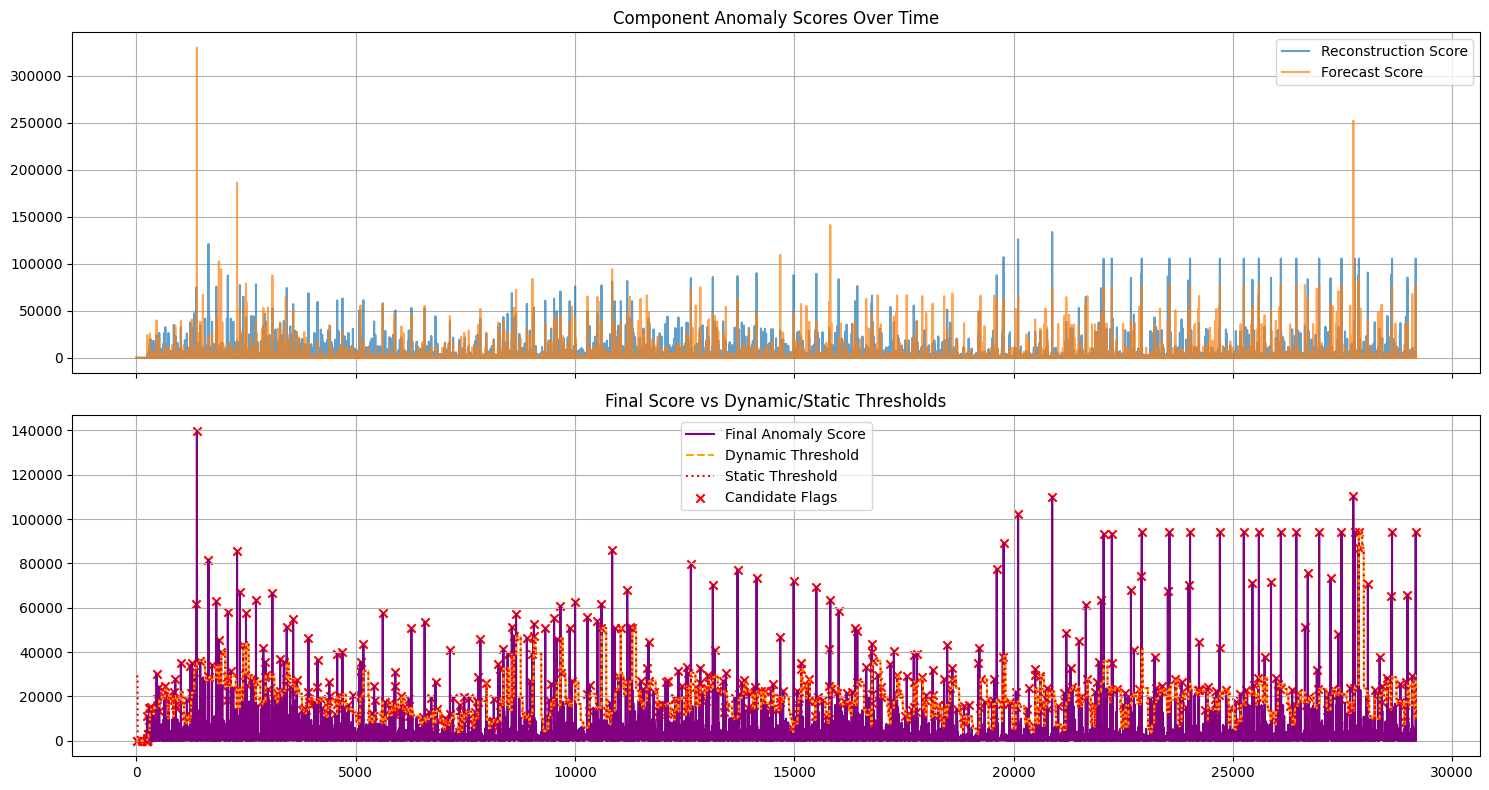

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Subplot 1: Components
axes[0].plot(hybrid_stream['window_id'], hybrid_stream['recon_score'], label='Reconstruction Score', alpha=0.7)
axes[0].plot(hybrid_stream['window_id'], hybrid_stream['forecast_score'], label='Forecast Score', alpha=0.7)
axes[0].set_title('Component Anomaly Scores Over Time')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Dynamic vs Final
axes[1].plot(hybrid_stream['window_id'], hybrid_stream['final_score'], label='Final Anomaly Score', color='purple')
axes[1].plot(hybrid_stream['window_id'], hybrid_stream['calculated_dynamic_threshold'], label='Dynamic Threshold', color='orange', linestyle='--')
axes[1].plot(hybrid_stream['window_id'], hybrid_stream['final_threshold'], label='Static Threshold', color='red', linestyle=':')

# Highlight candidates
candidate_indices = hybrid_stream[hybrid_stream['is_candidate']]['window_id']
axes[1].scatter(candidate_indices, hybrid_stream[hybrid_stream['is_candidate']]['final_score'], color='red', marker='x', label='Candidate Flags')

axes[1].set_title('Final Score vs Dynamic/Static Thresholds')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'hybrid' / 'paper_style_timeseries.png')
plt.show()